In [ ]:
import pandas as pd
import tarfile
import json
import numpy as np
import csv
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import permutation_test

# Core Result Analysis #

In [ ]:
def make_relevancy_dict(dataset, folder, include_non_relevant=True):
    relevancies = {}
    if include_non_relevant:
        non_relevant = {}

    if dataset == "athome4":
        qrels_path = folder + "/tr-2016-topics-judgments.tgz"
    elif dataset in ["athome1", 'athome2', 'athome3']:
        qrels_path = folder + "/tr-2015-topics-judgments.tgz"
    else:
        return None

    with tarfile.open(qrels_path, 'r:gz') as tar:
        if "tr-2016-topics-judgments.tgz" in qrels_path:
            qrels_file = tar.extractfile('athome4.facetsandqrels')
            if qrels_file is None:
                raise FileNotFoundError("Missing athome4.facetsandqrels in qrels tar.")
            with qrels_file:
                qrels = qrels_file.read().decode('utf-8', 'replace')
            
                
            for line in qrels.splitlines():
                line_parts = line.split()

                if len(line_parts) == 4:
                    topid = line_parts[0]
                    docno = line_parts[1]
                    rel = int(line_parts[2])

                    if (rel >= 1):
                        if topid in relevancies:
                            relevancies[topid].add(docno)
                        else:
                            relevancies[topid] = {docno}
                    elif (rel == 0) and include_non_relevant:
                        if topid in non_relevant:
                            non_relevant[topid].add(docno)
                        else:
                            non_relevant[topid] = {docno}

        elif "tr-2015-topics-judgments.tgz" in qrels_path:
            index = {i.name: i for i in tar.getmembers()}
            for key in index.keys():
                if dataset in key:
                    body = tar.extractfile(key)
                    if body is not None:
                        text = body.read().decode('utf-8', 'replace')
                        count = 0
                        for line in text.splitlines():
                            count += 1
                            if count == 1:
                                continue
                            docno, topid, rel = line.split('\t')
                            rel = int(rel)
                            topic = topid[6:]
                            if rel >= 1:
                                if topic in relevancies:
                                    relevancies[topic].add(docno)
                                else:
                                    relevancies[topic] = {docno}
                            elif rel < 1 and include_non_relevant:
                                if topid in non_relevant:
                                    non_relevant[topic].add(docno)
                                else:
                                    non_relevant[topic] = {docno}
    # for topic in relevancies:
    #     print(f"Topic {topic} has {len(relevancies[topic])} relevant documents")
    if include_non_relevant:
        return relevancies, non_relevant
    else:
        return relevancies

def cumulative_gain_curves(csv_path, topic_col=0, relevance_col=2, skip_unjudged=False, rels=None, non_rels=None, docno_col=1):
    """Return per-topic cumulative gain curves from a results CSV."""
    data = pd.read_csv(csv_path, header=None, dtype={topic_col: str, docno_col: str})
    rel = {}
    non_rel = {}
    unjudged = {}

    topic_values = data.iloc[:, topic_col].astype(str)

    for topic, group in data.groupby(topic_values, sort=False):
        relevances = pd.to_numeric(group.iloc[:, relevance_col], errors="coerce").fillna(0)

        if skip_unjudged:
            relevances = relevances[relevances != -1]

        if non_rels is None:
            unjudged[topic] = (relevances == -1).cumsum().tolist()
            non_rel[topic] = (relevances == 0).cumsum().tolist()
            rel[topic] = (relevances >= 1).cumsum().tolist()

        else:
            docnos = group.iloc[:, docno_col]
            relevant = rels[topic]
            non_relevant = non_rels.get(topic, set())
            judged = relevant | non_relevant

            unjudged[topic] = (~docnos.isin(judged)).cumsum().tolist()
            non_rel[topic] = (docnos.isin(non_relevant)).cumsum().tolist()
            rel[topic] = (docnos.isin(relevant)).cumsum().tolist()

    return rel, non_rel, unjudged

def normalized_cumulative_gain_curves(csv_path, relevancies, topic_col=0, relevance_col=2, skip_unjudged=False, non_rels=None, docno_col=1):
    """Return cumulative gain curves normalized by the number of relevant items per topic."""
    rel, non_rel, unjudged = cumulative_gain_curves(csv_path, topic_col=topic_col, relevance_col=relevance_col, skip_unjudged=skip_unjudged,
                                                     rels=relevancies, non_rels=non_rels, docno_col=docno_col)
    rel_curve = {}
    non_rel_curve = {}
    uj_curve = {}

    for topic in relevancies:
        total_count = rel[topic][-1] + non_rel[topic][-1] + unjudged[topic][-1]
        total_relevant = len(relevancies[topic])
        rel_curve[topic] = [value / total_relevant for value in rel[topic]]
        non_rel_curve[topic] = [value / total_relevant for value in non_rel[topic]]
        uj_curve[topic] = [value / total_count for value in unjudged[topic]]

    return rel_curve, non_rel_curve, uj_curve

def normalized_gain_curves_for_folder(folder_name, dataset, relevancies, topic_col=0, relevance_col=2, skip_unjudged=False, non_rels=None, docno_col=1):
    """Return normalized gain curves for every CSV file under a folder."""
    rel_curves = {}
    non_rel_curves = {}
    uj_curves = {}

    root_path = Path(folder_name)
    model_code_map = {
    'harrier-oss-v1-0.6b': "H600M",
    'harrier-oss-v1-270m': "H270M",
    'Qwen3-Embedding-0.6B': "Q600M",
    'Qwen3-Embedding-4B': "Q4B",
    'Qwen3-Embedding-8B': "Q8B",
    }

    append = ""
    if folder_name == 'results2':
        append = "_reg2"

    for csv_path in sorted(root_path.rglob("*.csv")):
        relative_parts = csv_path.relative_to(root_path).parts

        file_dset = relative_parts[0]
        if file_dset != dataset:
            continue

        if len(relative_parts) == 2 and csv_path.name == "baseline.csv":
            run_name = "baseline"
        else:
            model_name = relative_parts[2] if len(relative_parts) > 2 else csv_path.parent.name
            model_code = model_code_map.get(model_name, model_name)

            file_stem = csv_path.stem
            if file_stem.startswith("All"):
                result_type = "All"
            elif file_stem.startswith("Judged"):
                result_type = "Judged"
            else:
                result_type = file_stem.split("_")[0]
            result_size = file_stem.rsplit("_", 1)[-1]
            run_name = f"{model_code}_{result_type}_{result_size}{append}"

        rel_curve, non_rel_curve, uj_curve = normalized_cumulative_gain_curves(
            str(csv_path),
            relevancies,
            topic_col=topic_col,
            relevance_col=relevance_col,
            skip_unjudged=skip_unjudged,
            non_rels=non_rels,
            docno_col=docno_col
        )

        rel_curves[run_name] = rel_curve
        non_rel_curves[run_name] = non_rel_curve
        uj_curves[run_name] = uj_curve

    return rel_curves, non_rel_curves, uj_curves

def read_nimesh_results(folder_path, dataset, rels, non_rels=None, skip_unjudged=False):
    rel = {}
    non_rel = {}
    unjudged = {}
    root_path = Path(folder_path)
    for file in root_path.iterdir():
        if file.is_file():
            topic = file.name

            if topic[0] == 'a':
                topic = topic[6:]

            if topic[0] != dataset[-1]:
                continue

            relevant = rels[topic]
            non_relevant = set()
            if non_rels is not None:
                non_relevant = non_rels.get(topic, set())
            judged = relevant | non_relevant
            data = pd.read_csv(file, delimiter=" ", header=None, dtype={0: str})

            if skip_unjudged:
                data = data[data.iloc[:,0].isin(judged)]

            rel_results = (data.iloc[:,0].isin(relevant)).cumsum().tolist()
            unjudged_results = (~data.iloc[:,0].isin(judged)).cumsum().tolist()
            non_rel_results = (data.iloc[:,0].isin(non_relevant)).cumsum().tolist()
       
            total_relevant = len(rels.get(topic, ()))
            rel[topic] = [value / total_relevant for value in rel_results]
            non_rel[topic] = [value / total_relevant for value in non_rel_results]
            unjudged[topic] = [value / total_relevant for value in unjudged_results]

    return rel, non_rel, unjudged

def avg_results(results, rels):
    avg_curves = {}
    for run, curves in results.items():
        R = 0.1
        gain_curve = []
        while R < 2.01:
            y_val = 0
            topics = 0
            for topic in curves.keys():
                index = int(max(R-0.01, 0) * len(rels[topic]))
                curve = curves[topic]
                if index < len(curve):
                    val = curve[index]
                    topics += 1
                    y_val += val

            if topics == 0:
                break
            
            y_val /= topics
            gain_curve.append(y_val)
            R += (0.1)

        avg_curves[run] = gain_curve

    return avg_curves

def make_metric_df(rel, non_rel, uj, ratio, cum_ratio, fake_rel, fake_cum_rel):
    df = pd.DataFrame(index=rel.keys())
    
    df["0.5 Recall"] = [rel[k][4] for k in df.index]
    df["1.0 Recall"] = [rel[k][9] for k in df.index]
    df["1.5 Recall"] = [rel[k][14] for k in df.index]
    df["2.0 Recall"] = [rel[k][-1] for k in df.index]
    df["Non Rel Recall"] = [non_rel[k][-1] for k in df.index]
    df["Unjudged Recall"] = [uj[k][-1] for k in df.index]
    # df["Fake 0.5 Recall"] = [fake_rel[k][5] for k in df.index]
    # df["Fake 1.0 Recall"] = [fake_rel[k][10] for k in df.index]
    # df["Fake 1.5 Recall"] = [fake_rel[k][15] for k in df.index]
    # df["Fake 2.0 Recall"] = [fake_rel[k][20] for k in df.index]
    # df["Fake 2.0 Cum Recall"] = [fake_cum_rel[k][20] for k in df.index]
    # df["0.5 Cum Rel Percent"] = [cum_ratio[k][5] for k in df.index]
    # df["1.0 Cum Rel Percent"] = [cum_ratio[k][10] for k in df.index]
    # df["1.5 Cum Rel Percent"] = [cum_ratio[k][15] for k in df.index]
    # df["2.0 Cum Rel Percent"] = [cum_ratio[k][20] for k in df.index]

    return df

def make_ratios(rel_curves, non_rel_curves):
    ratios = {}
    cum_ratios = {}
    for run in rel_curves.keys():
        rel_data = rel_curves[run]
        non_rel_data = non_rel_curves[run]
        ratios[run] = [rel_data[0] / (rel_data[0] + non_rel_data[0])]
        cum_ratios[run] = [rel_data[0] / (rel_data[0] + non_rel_data[0])]

        for i in range(1, 20):
            rel = rel_data[i]
            non_rel = non_rel_data[i]
            cum_ratios[run].append(rel / (rel + non_rel))

            prev_rel = rel_data[i-1]
            prev_non = non_rel_data[i-1]
            rel_diff = rel - prev_rel
            non_diff = non_rel - prev_non
            ratios[run].append(rel_diff / (rel_diff + non_diff))
    
    return ratios, cum_ratios

def fake_recall(ratios, cum_ratios, rel, unjudged):
    fake_recall = {}
    fake_cum_recall = {}
    uj_counts = {}
    
    for run in rel.keys():
        rel_data = rel[run]
        unjudged_data = unjudged[run]
        ratio_data = ratios[run]
        cum_ratio_data = cum_ratios[run]

        fake_recall[run] = [unjudged_data[0]*ratio_data[0] + rel_data[0]]
        fake_cum_recall[run] = [unjudged_data[0]*cum_ratio_data[0] + rel_data[0]]
        uj_counts[run] = [unjudged_data[0]]

        for i in range(1,20):
            new_unjudged = unjudged_data[i] - unjudged_data[i-1]
            uj_counts[run].append(new_unjudged)
            new_rel = rel_data[i] - rel_data[i-1]
            fake_recall[run].append(new_unjudged*ratio_data[i] + new_rel + fake_recall[run][i-1])
            fake_cum_recall[run].append(unjudged_data[i]*cum_ratio_data[i] + rel_data[i])
    
    return fake_recall, fake_cum_recall, uj_counts

def randomization_test(
    results_a,
    results_b,
    relevancies,
    alternative="two-sided",
    n_resamples=1_000,
    random_state=0,
):
    """Compare two pre-averaged run mappings using a paired randomization test.

    ``results_a`` and ``results_b`` map topic IDs to per-query value series.
    The paired values are taken at index ``2 * len(relevancies[topic]) - 1``.

    The test statistic is the mean paired difference:

        mean(results_a - results_b)

    For each randomization, the two values within every topic pair are
    randomly swapped. Set ``n_resamples=np.inf`` to perform an exact test
    when the number of topics is small enough.
    """
    common_topics = [
        topic
        for topic in relevancies
        if topic in results_a and topic in results_b
    ]

    if not common_topics:
        raise ValueError("The two result mappings have no topics in common.")

    values_a = []
    values_b = []

    for topic in common_topics:
        index = min(
            2 * len(relevancies[topic]) - 1,
            len(results_a[topic]) - 1,
            len(results_b[topic]) - 1,
        )

        if index < 0:
            raise ValueError(
                f"Topic {topic} does not have a valid value index."
            )

        try:
            values_a.append(results_a[topic][index])
            values_b.append(results_b[topic][index])
        except IndexError as error:
            raise ValueError(
                f"Topic {topic} does not have a value at index {index}."
            ) from error

    values_a = np.asarray(values_a)
    values_b = np.asarray(values_b)

    def mean_difference(a, b):
        return np.mean(a - b)

    test = permutation_test(
        data=(values_a, values_b),
        statistic=mean_difference,
        permutation_type="samples",
        alternative=alternative,
        n_resamples=n_resamples,
        random_state=random_state,
        vectorized=False,
    )

    return test, values_a, values_b

def augment_relevancy_dicts(rels, non_rels, llm_judgements):
    """Augment human qrels with LLM labels for human-unjudged documents.

    Human judgements take precedence when a document appears in either input
    dictionary. LLM label 1 is added to ``rels`` and label 0 to ``non_rels``.
    The input dictionaries are not modified.
    """
    augmented_rels = {
        topic: set(documents)
        for topic, documents in rels.items()
    }
    augmented_non_rels = {
        topic: set(documents)
        for topic, documents in non_rels.items()
    }

    added_relevant = 0
    added_non_relevant = 0

    for topic, documents in llm_judgements.items():
        relevant_documents = augmented_rels.setdefault(topic, set())
        non_relevant_documents = augmented_non_rels.setdefault(topic, set())
        human_judged_documents = relevant_documents | non_relevant_documents

        for docno, llm_label in documents.items():
            if docno in human_judged_documents:
                continue

            llm_label = int(llm_label)
            if llm_label >= 1:
                relevant_documents.add(docno)
                added_relevant += 1
            elif llm_label == 0:
                non_relevant_documents.add(docno)
                added_non_relevant += 1
            else:
                raise ValueError(
                    f'Expected an LLM label of 0 or 1, got {llm_label!r} '
                    f'for topic {topic}, docno {docno}.'
                )

    print(
        f'Added {added_relevant:,} relevant and '
        f'{added_non_relevant:,} non-relevant LLM judgements.'
    )
    return augmented_rels, augmented_non_rels

In [ ]:
datasets = ['athome1', 'athome2', 'athome3', 'athome4']
full_results = {"rel_curves": {}, "non_rel_curves": {}, "uj_curves": {}, "ratios": {}, "cum_ratios": {}, "fake_recall": {}, "fake_cum_recall": {}, "metrics": {}, "stat_tests": {}}

for dataset in datasets:

    og_rels, non_rels = make_relevancy_dict(dataset, 'tgz_files', True)

    if dataset == 'athome4':
        with open('gpt-oss-judgements.json', 'r', encoding='utf-8') as file:
            llm_judgements = json.load(file)
            rels, non_rels = augment_relevancy_dicts(og_rels, non_rels, llm_judgements)
        # rels = og_rels # Uncomment this, and comment above 3 lines to ignore llm_judgements
    else:
        non_rels = None
        rels = og_rels

    

    rel_curve, non_rel_curve, uj_curve = normalized_gain_curves_for_folder('results', dataset, rels, non_rels=non_rels)
    # rel2, non_rel2, uj2 = normalized_gain_curves_for_folder('results2', DATASET, rels)
    # rel_curve.update(rel2)
    # non_rel_curve.update(non_rel2)
    # uj_curve.update(uj2)

    # nimesh_rel, nimesh_non_rel, nimesh_uj = read_nimesh_results('nimesh_results', dataset, rels, non_rels)

    # Wilcoxon test against baseline with recall of each query at normalized effort of 2
    full_results["stat_tests"][dataset] = {}
    if dataset == 'athome4':
        for run in rel_curve.keys():
            full_results["stat_tests"][dataset][run] = randomization_test(rel_curve[run], rel_curve['baseline'], rels)

    # rel_curve['baseline'] = nimesh_rel
    # non_rel_curve['baseline'] = nimesh_non_rel
    # uj_curve['baseline'] = nimesh_uj

    full_results['rel_curves'][dataset] = avg_results(rel_curve, og_rels)
    full_results['non_rel_curves'][dataset] = avg_results(non_rel_curve, og_rels)
    full_results['uj_curves'][dataset] = avg_results(uj_curve, og_rels)
    del rel_curve, non_rel_curve, uj_curve

    full_results['ratios'][dataset], full_results['cum_ratios'][dataset] = make_ratios(full_results['rel_curves'][dataset], 
                                                      full_results['non_rel_curves'][dataset])
    fake_recalls, fake_cum_recalls, uj_counts = fake_recall(full_results['ratios'][dataset], 
                                                            full_results['cum_ratios'][dataset], 
                                                            full_results['rel_curves'][dataset], 
                                                            full_results['uj_curves'][dataset])

    full_results['fake_recall'][dataset] = fake_recalls
    full_results['fake_cum_recall'][dataset] = fake_cum_recalls
    del fake_recalls, fake_cum_recalls

    full_results['metrics'][dataset] = make_metric_df(full_results['rel_curves'][dataset],
                                                    full_results['non_rel_curves'][dataset],
                                                    full_results['uj_curves'][dataset],
                                                    full_results['ratios'][dataset],
                                                    full_results['cum_ratios'][dataset],
                                                    full_results['fake_recall'][dataset],
                                                    full_results['fake_cum_recall'][dataset]).sort_values(by="2.0 Recall", ascending=False)

# rel3, non_rel3, uj3 = normalized_gain_curves_for_folder('results', DATASET, rels, skip_unjudged=True)
# nimesh3, nimesh_non3, nimesh_uj3 = read_nimesh_results('nimesh_results', DATASET, rels, non_rels, skip_unjudged=True)
# rel3['nimesh'] = nimesh3
# non_rel3['nimesh'] = nimesh_non3
# rel_ignoreuj_curves = avg_results(rel3, rels)
# non_rel_ignoreuj_curves = avg_results(non_rel3, rels)
# del rel3, non_rel3, uj3, nimesh_uj3, nimesh3, nimesh_non3

# Result Summaries #

In [ ]:
metrics = full_results['metrics']['athome4']
metrics.sort_values(by='Non Rel Recall')
metrics.head(40)

In [ ]:
runs_to_compare = ['baseline', 'Q8B_Judged_32', 'Q4B_Judged_32', 'Q600M_Judged_32', 'H270M_Judged_32', 'H600M_Judged_256']
x_vals = [i/10 for i in range(1,21)]
fig, axes = plt.subplots(2,2, figsize=(10,10))

for ax in axes.ravel():
    ax.set_xlabel('Normalized Effort')
    ax.set_ylabel('Average Recall')
    ax.set_ylim(0,1)
    ax.set_xlim(0,2)
    ax.minorticks_on()
    for x in [0.5, 1, 1.5]:
        ax.axvline(x=x, linestyle='--', linewidth=1)

    for y in [0.2,0.4,0.6,0.8, 1.0, 1.2, 1.4]:
        ax.axhline(y=y, color='r', linestyle='--', linewidth=0.25)

ax = axes[0,0]
for run in runs_to_compare:
    try:
        ax.plot(x_vals, full_results['rel_curves']['athome1'][run], label=run)
    except KeyError as e:
        pass
ax.set_title("Athome1 Recall Curves")
ax.legend()

ax = axes[0,1]
for run in runs_to_compare:
    try:
        ax.plot(x_vals, full_results['rel_curves']['athome2'][run], label=run)
    except KeyError as e:
        pass
ax.set_title("AtHome2 Recall Curves")
ax.legend()

ax = axes[1,0]
for run in runs_to_compare:
    try:
        ax.plot(x_vals, full_results['rel_curves']['athome3'][run], label=run)
    except KeyError as e:
        pass
ax.set_title("Athome3 Recall Curves")
ax.legend()

ax = axes[1,1]
for run in runs_to_compare:
    try:
        ax.plot(x_vals, full_results['rel_curves']['athome4'][run], label=run)
    except KeyError as e:
        pass
ax.set_title("AtHome4 Recall Curves")
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

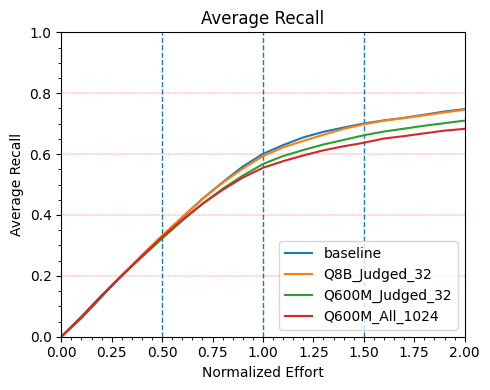

In [10]:
runs_to_compare = ['baseline', 'Q8B_Judged_32', 'Q600M_Judged_32', 'Q600M_All_1024']

fig, ax = plt.subplots(figsize=(5,4))

ax.set_xlabel('Normalized Effort')
ax.set_ylabel('Average Recall')
ax.set_ylim(0,1)
ax.set_xlim(0,2)
# ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
ax.minorticks_on()
for x in [0.5, 1, 1.5]:
    ax.axvline(x=x, linestyle='--', linewidth=1)

for y in [0.2,0.4,0.6,0.8, 1.0, 1.2, 1.4]:
    ax.axhline(y=y, color='r', linestyle='--', linewidth=0.25)

x_vals_with_zero = [0] + x_vals
for run in runs_to_compare:
    try:
        results = full_results['rel_curves']['athome4'][run]
        results_with_zero = [0] + results
        ax.plot(x_vals_with_zero, results_with_zero, label=run)
    except KeyError as e:
        pass
ax.set_title("Average Recall")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
plt.close()

# Comparing Relevant / Non-Relevant Ratios #

In [ ]:
# Smooth only the per-run ratio curves with a 3-point moving average
smoothed_ratios = {}

for dataset, runs in full_results['ratios'].items():
    smoothed_ratios[dataset] = {}
    for run, values in runs.items():
        smoothed = []
        for i in range(len(values)):
            window = values[max(0, i - 2):i + 1]
            smoothed.append(sum(window) / len(window))
        smoothed_ratios[dataset][run] = smoothed

In [ ]:
runs_to_compare = ['baseline', 'Q8B_Judged_256', 'Q4B_Judged_128', 'H270M_Judged_32', 'H600M_Judged_64', 'Q600M_Judged_64']

x_vals = [i/10 for i in range(1,21)]

fig, axes = plt.subplots(4,4, figsize=(16,16))

for ax in axes.ravel():
    ax.set_xlabel('Normalized Effort')
    ax.set_ylim(0,1)
    ax.set_xlim(0,2)
    ax.minorticks_on()
    for x in [0.5, 1, 1.5]:
        ax.axvline(x=x, linestyle='--', linewidth=1)
    for y in [0.2,0.4,0.6,0.8, 1.0, 1.2, 1.4]:
        ax.axhline(y=y, color='r', linestyle='--', linewidth=0.25)

for i in range(1,5):

    ax = axes[0,i-1]
    for run in runs_to_compare:
        ax.plot(x_vals, full_results['rel_curves'][f'athome{i}'][run], label=run)
    ax.set_ylabel('Average Recall')
    ax.set_title(f'Average Recall on AtHome{i}')

    ax = axes[1,i-1]
    for run in runs_to_compare:
        ax.plot(x_vals, full_results['non_rel_curves'][f'athome{i}'][run], label=run)
    ax.set_ylabel('Non-Relevant / # Rel Docs')
    ax.set_title(f'Non-Relevant Retrieval on AtHome{i}')

    ax = axes[2,i-1]
    for run in runs_to_compare:
        ax.plot(x_vals, smoothed_ratios[f'athome{i}'][run], label=run)
    ax.set_ylabel('Percent Relevant Docs')
    ax.set_title(f'Per-Interval Relevant Percentages on AtHome{i}')
    ax.axhline(y=0.5, color='g', linestyle='-', linewidth=0.5)

    ax = axes[3,i-1]
    for run in runs_to_compare:
        ax.plot(x_vals, full_results['cum_ratios'][f'athome{i}'][run], label=run)
    ax.set_ylabel('Cumulative Percent Relevant')
    ax.set_title(f'Cumulative Percent Relevant on AtHome{i}')


plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Statistical Signficance Results #

In [7]:
full_results['stat_tests']['athome4']['Q8B_Judged_32']

(WilcoxonResult(statistic=np.float64(256.0), pvalue=np.float64(0.6615589548322263)),
 array([0.93405114, 0.51295337, 0.85006435, 0.76858108, 0.57651547,
        0.65778961, 0.529431  , 0.99747134, 0.51709402, 0.87160494,
        0.75732218, 0.96073298, 0.53658537, 0.34653465, 0.79354839,
        0.91101695, 0.97154472, 0.85950413, 0.91791045, 0.9047619 ,
        0.91609195, 0.5899654 , 0.87876026, 0.8502994 , 0.74660633,
        0.81818182, 0.95      , 0.97497766, 0.53623188, 0.56050955,
        0.64251208, 0.74944666, 0.51530612, 0.46736842]),
 array([0.91184388, 0.38341969, 0.86808237, 0.93918919, 0.54005935,
        0.75146182, 0.50981033, 0.99797707, 0.58119658, 0.95308642,
        0.81589958, 0.95549738, 0.41463415, 0.32673267, 0.74516129,
        0.88276836, 0.95528455, 0.91735537, 0.87313433, 0.90095238,
        0.96666667, 0.5449827 , 0.85870556, 0.80239521, 0.67420814,
        0.92561983, 0.95      , 0.96157283, 0.58816425, 0.80254777,
        0.57487923, 0.72819832, 0.4438775

# Parameter Comparison #

In [79]:
columns = ["model", "mode", "sentences"] + [i for i in range(401, 435)]
topic_results_df = pd.DataFrame(columns=columns)

for run in full_results['stat_tests']['athome4'].keys():
    if run == "baseline":
        continue

    results = full_results['stat_tests']['athome4'][run][1]

    params = run.split("_")
    row_data = params + list(results)
    topic_results_df.loc[run] = row_data

In [ ]:
# Rank each parameter within complete matched runs for every topic.
parameter_columns = ["model", "sentences", "mode"]
topic_columns = [column for column in topic_results_df.columns if column not in parameter_columns]

if len(topic_columns) != 34:
    raise ValueError(f"Expected 34 topic columns, found {len(topic_columns)}.")

ranking_rows = topic_results_df.melt(
    id_vars=parameter_columns,
    value_vars=topic_columns,
    var_name="topic",
    value_name="score",
)
ranking_rows["score"] = pd.to_numeric(ranking_rows["score"], errors="coerce")
ranking_rows = ranking_rows.dropna(subset=["score"]).copy()

ranked_parameter_rows = []
comparison_coverage = []
for parameter in parameter_columns:
    other_parameters = [column for column in parameter_columns if column != parameter]
    grouping_columns = ["topic"] + other_parameters
    parameter_values = ranking_rows[parameter].dropna().unique()
    expected_value_count = len(parameter_values)
    grouped_rows = ranking_rows.groupby(grouping_columns, dropna=False)

    # Do not rank a setting when one of its alternatives is absent from the group.
    complete_group_mask = (
        grouped_rows[parameter].transform("nunique") == expected_value_count
    ) & (
        grouped_rows.size().reindex(ranking_rows.set_index(grouping_columns).index).to_numpy()
        == expected_value_count
    )
    parameter_rows = ranking_rows.loc[complete_group_mask].copy()
    parameter_rows["rank"] = (
        parameter_rows.groupby(grouping_columns, dropna=False)["score"]
        .rank(method="min", ascending=False)
        .astype("Int64")
    )
    score_group = parameter_rows.groupby(grouping_columns, dropna=False)["score"]
    parameter_rows["is_tie"] = (
        score_group.transform("nunique") == 1
    )
    parameter_rows["rank_label"] = parameter_rows["rank"].astype("string")
    parameter_rows.loc[parameter_rows["is_tie"], "rank_label"] = "Equal"
    parameter_rows["parameter"] = parameter
    parameter_rows["parameter_value"] = parameter_rows[parameter]
    ranked_parameter_rows.append(
        parameter_rows[
            ["parameter", "parameter_value", "topic", "rank", "rank_label", "score"]
            + other_parameters
        ]
    )
    comparison_coverage.append({
        "parameter": parameter,
        "complete_comparisons": len(parameter_rows) // expected_value_count,
        "rows_used": len(parameter_rows),
        "expected_values": expected_value_count,
    })

parameter_topic_ranks = pd.concat(ranked_parameter_rows, ignore_index=True)
parameter_rank_counts = (
    parameter_topic_ranks
    .groupby(["parameter", "parameter_value", "rank_label"], dropna=False)
    .size()
    .rename("topics")
    .reset_index()
)
comparison_coverage = pd.DataFrame(comparison_coverage)

comparison_coverage, parameter_rank_counts.sort_values(["parameter", "parameter_value", "rank_label"])

In [ ]:
df = ranked_parameter_rows[1]
print(df[df["rank_label"] == "Equal"])

In [ ]:
def make_graph(parameter, parameter_display_order, graph_title=None, y_lab="# Topics", x_lab="Parameter Value"):
    counts = (
        parameter_rank_counts[parameter_rank_counts["parameter"] == parameter]
        .pivot(index="parameter_value", columns="rank_label", values="topics")
        .fillna(0)
    )
    numeric_rank_columns = sorted(
        [column for column in counts.columns if column != "Equal"],
        key=lambda value: int(value),
    )
    counts = counts.reindex(
        columns=numeric_rank_columns + (["Equal"] if "Equal" in counts else []),
        fill_value=0,
    )
    if parameter in parameter_display_order:
        counts = counts.reindex(parameter_display_order[parameter], fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    counts.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(graph_title)
    ax.set_xlabel(x_lab)
    ax.set_ylabel(y_lab)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(title="Rank")
    plt.show()
    plt.close(fig)

In [ ]:
# Show one rank distribution graph at a time.
parameter_display_order = {
    "model": ["Q600M", "Q4B", "Q8B", "H270M", "H600M"],
    "sentences": sorted(
        parameter_rank_counts.loc[
            parameter_rank_counts["parameter"] == "sentences", "parameter_value"
        ].unique(),
        key=lambda value: int(value),
    ),
}

make_graph("mode", parameter_display_order, "Training Mode Comparison", x_lab="Mode", y_lab="Frequency of Rank over Topics")

# LLM Judgement Analysis #

In [ ]:
def make_relevancy_judgement_dict(dataset, folder):
    """Return per-topic document relevance judgements from the qrels tarball."""
    judgements = {}

    if dataset == "athome4":
        qrels_path = folder + "/tr-2016-topics-judgments.tgz"
    elif dataset in ["athome1", "athome2", "athome3"]:
        qrels_path = folder + "/tr-2015-topics-judgments.tgz"
    else:
        return None

    with tarfile.open(qrels_path, "r:gz") as tar:
        if dataset == "athome4":
            qrels_file = tar.extractfile("athome4.facetsandqrels")
            if qrels_file is None:
                raise FileNotFoundError("Missing athome4.facetsandqrels in qrels tar.")

            qrels = qrels_file.read().decode("utf-8", "replace")
            for line in qrels.splitlines():
                line_parts = line.split()
                if len(line_parts) == 4:
                    topic, docno, judgement = line_parts[0], line_parts[1], int(line_parts[2])
                    judgements.setdefault(topic, {})[docno] = judgement

        else:
            for member in tar.getmembers():
                if dataset not in member.name:
                    continue

                body = tar.extractfile(member)
                if body is None:
                    continue

                text = body.read().decode("utf-8", "replace")
                for line_number, line in enumerate(text.splitlines()):
                    if line_number == 0:
                        continue

                    docno, topic_id, judgement = line.split("\t")
                    topic = topic_id[6:]
                    judgements.setdefault(topic, {})[docno] = int(judgement)

    return judgements

def make_llm_human_confusion_matrix(
    llm_judgements,
    human_judgements,
    combine_relevant_labels=False,
):
    """Compare JSON LLM judgements with tarfile human judgements."""
    rows = []

    for topic, documents in llm_judgements.items():
        topic_human_judgements = human_judgements.get(str(topic), {})
        for docno, llm_label in documents.items():
            human_label = int(topic_human_judgements.get(str(docno), -1))
            llm_label = int(llm_label)

            if combine_relevant_labels:
                human_label = 1 if human_label in {1, 2} else human_label
                llm_label = 1 if llm_label in {1, 2} else llm_label

            rows.append({
                "human": human_label,
                "llm": llm_label,
            })

    labels = pd.DataFrame(rows, columns=["human", "llm"])
    human_labels = sorted(set(labels["human"]) | {-1})
    llm_labels = sorted(labels["llm"].unique())

    return pd.crosstab(labels["human"], labels["llm"]).reindex(
        index=human_labels,
        columns=llm_labels,
        fill_value=0,
    )

def plot_llm_error_depths(outcome_depths, bin_width=0.1, run_names=None):
    """Plot LLM outcomes by normalized retrieval depth."""
    if outcome_depths.empty:
        raise ValueError('No judged LLM outcomes were found in the result files.')

    plot_data = outcome_depths
    if run_names is not None:
        plot_data = plot_data[plot_data['run'].isin(run_names)]

    if plot_data.empty:
        raise ValueError('No outcomes remain after filtering to the selected runs.')

    max_depth = plot_data['normalized_depth'].max()
    bin_edges = np.arange(0, max_depth + bin_width, bin_width)
    if len(bin_edges) < 2:
        bin_edges = np.array([0, bin_width])

    plot_data = plot_data.copy()
    plot_data['depth_bin'] = pd.cut(
        plot_data['normalized_depth'],
        bins=bin_edges,
        include_lowest=True,
    )
    outcome_order = [
        'false positive',
        'false negative',
        'true positive',
        'true negative',
    ]
    counts = plot_data.groupby(
        ['depth_bin', 'outcome'],
        observed=False,
    ).size().unstack(fill_value=0)
    counts = counts.reindex(columns=outcome_order, fill_value=0)
    depth_centers = np.asarray([interval.mid for interval in counts.index], dtype=float)
    counts.index = depth_centers

    # Normalize each outcome across depth bins so each color sums to 1.
    outcome_proportions = counts.div(
        counts.sum(axis=0).replace(0, np.nan),
        axis=1,
    )
    cumulative = counts.cumsum()
    cumulative_share = cumulative.div(
        cumulative.iloc[-1].replace(0, np.nan),
    )

    colors = {
        'false positive': 'tab:red',
        'false negative': 'tab:blue',
        'true positive': 'tab:green',
        'true negative': 'tab:gray',
    }
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    bar_width = bin_width * 0.16
    bar_offsets = np.array([-0.30, -0.10, 0.10, 0.30]) * bin_width
    for offset, outcome in zip(bar_offsets, outcome_order):
        axes[0].bar(
            depth_centers + offset,
            outcome_proportions[outcome],
            width=bar_width,
            color=colors[outcome],
            edgecolor='white',
            linewidth=0.6,
            label=outcome,
        )

    axes[0].set_title('Distribution of LLM outcomes by normalized retrieval depth')
    axes[0].set_xlabel('Retrieval rank / human-relevant document count')
    axes[0].set_ylabel('Proportion of outcome')
    axes[0].set_ylim(0, 0.25)
    axes[0].set_xlim(0, max_depth + bin_width / 2)
    axes[0].tick_params(axis='x', labelbottom=True)
    axes[0].legend(title='Outcome', ncol=2)

    for outcome in outcome_order:
        axes[1].plot(
            depth_centers,
            cumulative_share[outcome],
            color=colors[outcome],
            marker='o',
            label=outcome,
        )

    axes[1].set_title('Cumulative LLM outcomes by normalized retrieval depth')
    axes[1].set_xlabel('Retrieval rank / human-relevant document count')
    axes[1].set_ylabel('Cumulative share of outcomes')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlim(0, max_depth + bin_width / 2)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend(title='Outcome', ncol=2)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return counts, cumulative_share

def collect_llm_error_depths(
    folder_name,
    dataset,
    rels,
    non_rels,
    llm_judgements,
    topic_col=0,
    docno_col=1,
    max_depth=None,
    result_file=None,
):
    """Collect LLM judgement outcomes by normalized retrieval depth.

    Only documents with both a human judgement and an LLM judgement are used.
    Normalized depth is one-based retrieval rank divided by the number of
    human-relevant documents for that topic.

    ``result_file`` may be a filename, a path relative to ``folder_name``, a
    workspace-relative path, or an absolute path. ``None`` includes all files.
    """
    outcome_rows = []
    root_path = Path(folder_name)
    requested_file = Path(result_file) if result_file is not None else None
    requested_text = requested_file.as_posix() if requested_file is not None else None
    requested_absolute = (
        requested_file.resolve().as_posix()
        if requested_file is not None
        else None
    )
    root_absolute = root_path.resolve()

    model_code_map = {
        'harrier-oss-v1-0.6b': 'H600M',
        'harrier-oss-v1-270m': 'H270M',
        'Qwen3-Embedding-0.6B': 'Q600M',
        'Qwen3-Embedding-4B': 'Q4B',
        'Qwen3-Embedding-8B': 'Q8B',
    }

    for csv_path in sorted(root_path.rglob('*.csv')):
        relative_parts = csv_path.relative_to(root_path).parts
        if not relative_parts or relative_parts[0] != dataset:
            continue

        relative_file = csv_path.relative_to(root_path).as_posix()
        matches_result_file = requested_file is None
        if requested_file is not None:
            matches_result_file = (
                requested_text in {csv_path.name, relative_file}
                or csv_path.resolve().as_posix() == requested_absolute
                or (
                    not requested_file.is_absolute()
                    and (Path.cwd() / requested_file).resolve() == csv_path.resolve()
                )
                or (
                    not requested_file.is_absolute()
                    and (root_absolute / requested_file).resolve() == csv_path.resolve()
                )
            )
        if not matches_result_file:
            continue

        model_name = relative_parts[2] if len(relative_parts) > 2 else csv_path.parent.name
        model_code = model_code_map.get(model_name, model_name)
        run_name = f'{model_code}_{csv_path.stem}'
        data = pd.read_csv(
            csv_path,
            header=None,
            dtype={topic_col: str, docno_col: str},
        )

        for rank, row in enumerate(data.itertuples(index=False), start=1):
            topic = str(row[topic_col])
            docno = str(row[docno_col])
            relevant_docs = rels.get(topic, set())
            non_relevant_docs = non_rels.get(topic, set())
            llm_docs = llm_judgements.get(topic, {})

            if docno in relevant_docs:
                human_label = 1
            elif docno in non_relevant_docs:
                human_label = 0
            else:
                continue

            if docno not in llm_docs or not relevant_docs:
                continue

            llm_label = int(llm_docs[docno])
            if llm_label == 1 and human_label == 1:
                outcome = 'true positive'
            elif llm_label == 0 and human_label == 0:
                outcome = 'true negative'
            elif llm_label == 1 and human_label == 0:
                outcome = 'false positive'
            elif llm_label == 0 and human_label == 1:
                outcome = 'false negative'
            else:
                raise ValueError(
                    f'Expected an LLM label of 0 or 1, got {llm_label!r} '
                    f'for topic {topic}, docno {docno}.'
                )

            normalized_depth = rank / len(relevant_docs)
            if max_depth is not None and normalized_depth > max_depth:
                continue

            outcome_rows.append({
                'run': run_name,
                'result_file': relative_file,
                'topic': topic,
                'docno': docno,
                'rank': rank,
                'normalized_depth': normalized_depth,
                'outcome': outcome,
            })

    return pd.DataFrame(outcome_rows)

def plot_llm_fp_tp_rates(outcome_depths, bin_width=0.1, run_names=None):
    """Plot false-positive and true-positive rates by normalized depth.

    Interval rates use outcomes within each depth bin. Cumulative rates use
    all outcomes retrieved up to each depth bin.
    """
    if outcome_depths.empty:
        raise ValueError('No judged LLM outcomes were found in the result files.')

    plot_data = outcome_depths
    if run_names is not None:
        plot_data = plot_data[plot_data['run'].isin(run_names)]

    if plot_data.empty:
        raise ValueError('No outcomes remain after filtering to the selected runs.')

    max_depth = plot_data['normalized_depth'].max()
    bin_edges = np.arange(0, max_depth + bin_width, bin_width)
    if len(bin_edges) < 2:
        bin_edges = np.array([0, bin_width])

    plot_data = plot_data.copy()
    plot_data['depth_bin'] = pd.cut(
        plot_data['normalized_depth'],
        bins=bin_edges,
        include_lowest=True,
    )
    counts = plot_data.groupby(
        ['depth_bin', 'outcome'],
        observed=False,
    ).size().unstack(fill_value=0)
    counts = counts.reindex(
        columns=['false positive', 'false negative', 'true positive', 'true negative'],
        fill_value=0,
    )
    depth_centers = np.asarray([interval.mid for interval in counts.index], dtype=float)
    counts.index = depth_centers

    interval_rates = pd.DataFrame(index=depth_centers)
    interval_rates['false positive rate'] = counts['false positive'] / (
        counts['false positive'] + counts['true negative']
    ).replace(0, np.nan)
    interval_rates['true positive rate'] = counts['true positive'] / (
        counts['true positive'] + counts['false negative']
    ).replace(0, np.nan)

    cumulative_counts = counts.cumsum()
    cumulative_rates = pd.DataFrame(index=depth_centers)
    cumulative_rates['false positive rate'] = cumulative_counts['false positive'] / (
        cumulative_counts['false positive'] + cumulative_counts['true negative']
    ).replace(0, np.nan)
    cumulative_rates['true positive rate'] = cumulative_counts['true positive'] / (
        cumulative_counts['true positive'] + cumulative_counts['false negative']
    ).replace(0, np.nan)

    colors = {
        'false positive rate': 'tab:red',
        'true positive rate': 'tab:green',
    }
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for rate_name in colors:
        axes[0].plot(
            depth_centers,
            interval_rates[rate_name],
            marker='o',
            color=colors[rate_name],
            label=rate_name,
        )
        axes[1].plot(
            depth_centers,
            cumulative_rates[rate_name],
            marker='o',
            color=colors[rate_name],
            label=rate_name,
        )

    axes[0].set_title('Interval FP and TP rates by normalized retrieval depth')
    axes[0].set_xlabel('Retrieval rank / human-relevant document count')
    axes[0].set_ylabel('Rate')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xlim(0, max_depth + bin_width / 2)
    axes[0].tick_params(axis='x', labelbottom=True)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()

    axes[1].set_title('Cumulative FP and TP rates by normalized retrieval depth')
    axes[1].set_xlabel('Retrieval rank / human-relevant document count')
    axes[1].set_ylabel('Rate')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlim(0, max_depth + bin_width / 2)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return interval_rates, cumulative_rates

In [59]:
athome4_judgements = make_relevancy_judgement_dict("athome4", "tgz_files")
with open('gpt-oss-judgements.json', 'r', encoding='utf-8') as file:
    llm_judgements = json.load(file)

confusion_matrix_from_judgements = make_llm_human_confusion_matrix(
    llm_judgements,
    athome4_judgements,
)

combined_confusion_matrix = make_llm_human_confusion_matrix(
    llm_judgements,
    athome4_judgements,
    combine_relevant_labels=True,
)

print(combined_confusion_matrix)

print(confusion_matrix_from_judgements)

llm        0      1
human              
-1     95038  11527
 0      6604   3320
 1      7538  17156
llm        0      1
human              
-1     95038  11527
 0      6604   3320
 1      6064  13140
 2      1474   4016


In [ ]:
# result_file = 'results/athome4/Qwen/Qwen3-Embedding-0.6B/JudgedChunks_32.csv'
result_file = None
# Examples:
# result_file = 'JudgedChunks_32.csv'
# result_file = 'athome4/Qwen/Qwen3-Embedding-8B/JudgedChunks_32.csv'

error_depths = collect_llm_error_depths(
    'results',
    'athome4',
    og_rels,
    non_rels,
    llm_judgements,
    max_depth=2.0,
    result_file=result_file,
)
if error_depths.empty:
    raise ValueError(
        f'No judged outcomes found for result_file={result_file!r}. '
        'Check that the path and filename exist under the results folder.'
    )

error_counts, cumulative_error_share = plot_llm_error_depths(error_depths)
interval_fp_tp_rates, cumulative_fp_tp_rates = plot_llm_fp_tp_rates(error_depths)
display(error_counts)
display(interval_fp_tp_rates)
display(cumulative_fp_tp_rates)